Running Non-Linearity Sweep...
Running Stochastic Simulations...


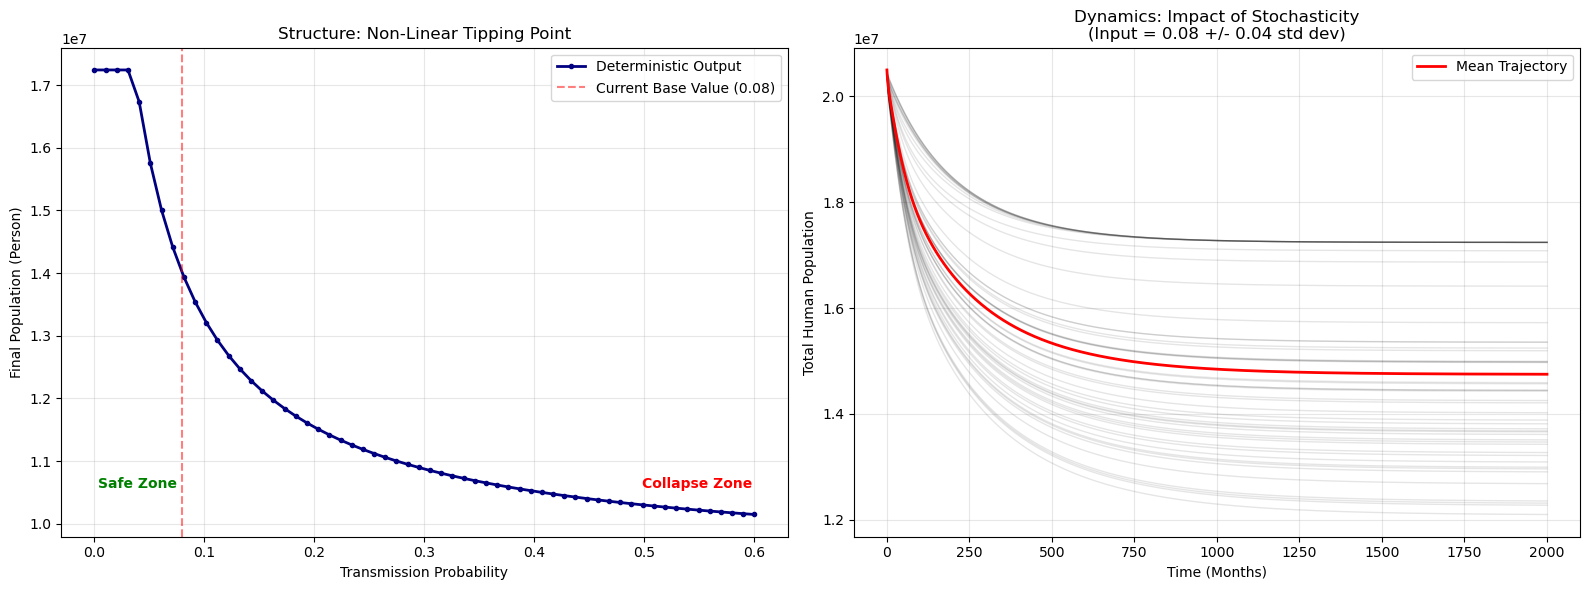


RESULTS ANALYSIS:
Input Noise (CV): 50.00%
Output Variation (CV): 11.18%
Non-Linear Amplification Factor: 0.22x
If Factor > 1.0, the system amplifies noise (sign of instability/non-linearity).


In [4]:
# Requirements: pip install pysd matplotlib numpy pandas
import pysd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

model_filename = 'balariainbali-stable.mdl'
try:
    model = pysd.read_vensim(model_filename)
except Exception as e:
    print(f"Error loading model: {e}")
    print("Ensure 'balariainbali-stable.mdl' is in the directory.")
    exit()

np.random.seed(42)

print("Running Non-Linearity Sweep...")
sweep_values = np.linspace(0.0, 0.6, 60)
final_populations = []

for val in sweep_values:
    res = model.run(params={'Transmission Probability': val},
                    return_columns=['Total human population'])
    final_populations.append(res['Total human population'].iloc[-1])

print("Running Stochastic Simulations...")

base_prob = 0.08 
std_dev = 0.04  
n_simulations = 50

simulations = []

for i in range(n_simulations):
    random_prob = np.random.normal(base_prob, std_dev)
    random_prob = max(0, min(1, random_prob)) 
    
    res = model.run(params={'Transmission Probability': random_prob},
                    return_columns=['Total human population'])
    simulations.append(res['Total human population'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Structure
ax1.plot(sweep_values, final_populations, color='navy', linewidth=2, marker='.', label='Deterministic Output')
ax1.set_title('Structure: Non-Linear Tipping Point')
ax1.set_xlabel('Transmission Probability')
ax1.set_ylabel('Final Population (Person)')
ax1.axvline(x=base_prob, color='red', linestyle='--', alpha=0.5, label=f'Current Base Value ({base_prob})')
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.text(0.05, 0.1, "Safe Zone", transform=ax1.transAxes, color='green', fontweight='bold')
ax1.text(0.8, 0.1, "Collapse Zone", transform=ax1.transAxes, color='red', fontweight='bold')

# Plot 2: Dynamics
for sim in simulations:
    ax2.plot(sim.index, sim, color='black', alpha=0.1, linewidth=1)

mean_traj = pd.concat(simulations, axis=1).mean(axis=1)
ax2.plot(mean_traj.index, mean_traj, color='red', linewidth=2, label='Mean Trajectory')

ax2.set_title(f'Dynamics: Impact of Stochasticity\n(Input = {base_prob} +/- {std_dev} std dev)')
ax2.set_xlabel('Time (Months)')
ax2.set_ylabel('Total Human Population')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

final_vals = [s.iloc[-1] for s in simulations]
input_cv = std_dev / base_prob
output_cv = np.std(final_vals) / np.mean(final_vals)
amplification = output_cv / input_cv

print(f"\nRESULTS ANALYSIS:")
print(f"Input Noise (CV): {input_cv:.2%}")
print(f"Output Variation (CV): {output_cv:.2%}")
print(f"Non-Linear Amplification Factor: {amplification:.2f}x")
print("If Factor > 1.0, the system amplifies noise (sign of instability/non-linearity).")